# The T7 terminator collection

# Data preparation

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
data, platemap = pr.load_platereader_data(
    data_file="20251027_T7_term_test_all.txt", 
    platemap_file="20251027_platemap.tsv", 
    platereader="biotek-cdk"
)
#data.to_csv('20251027_data.csv')

# Plotting summary kinetics

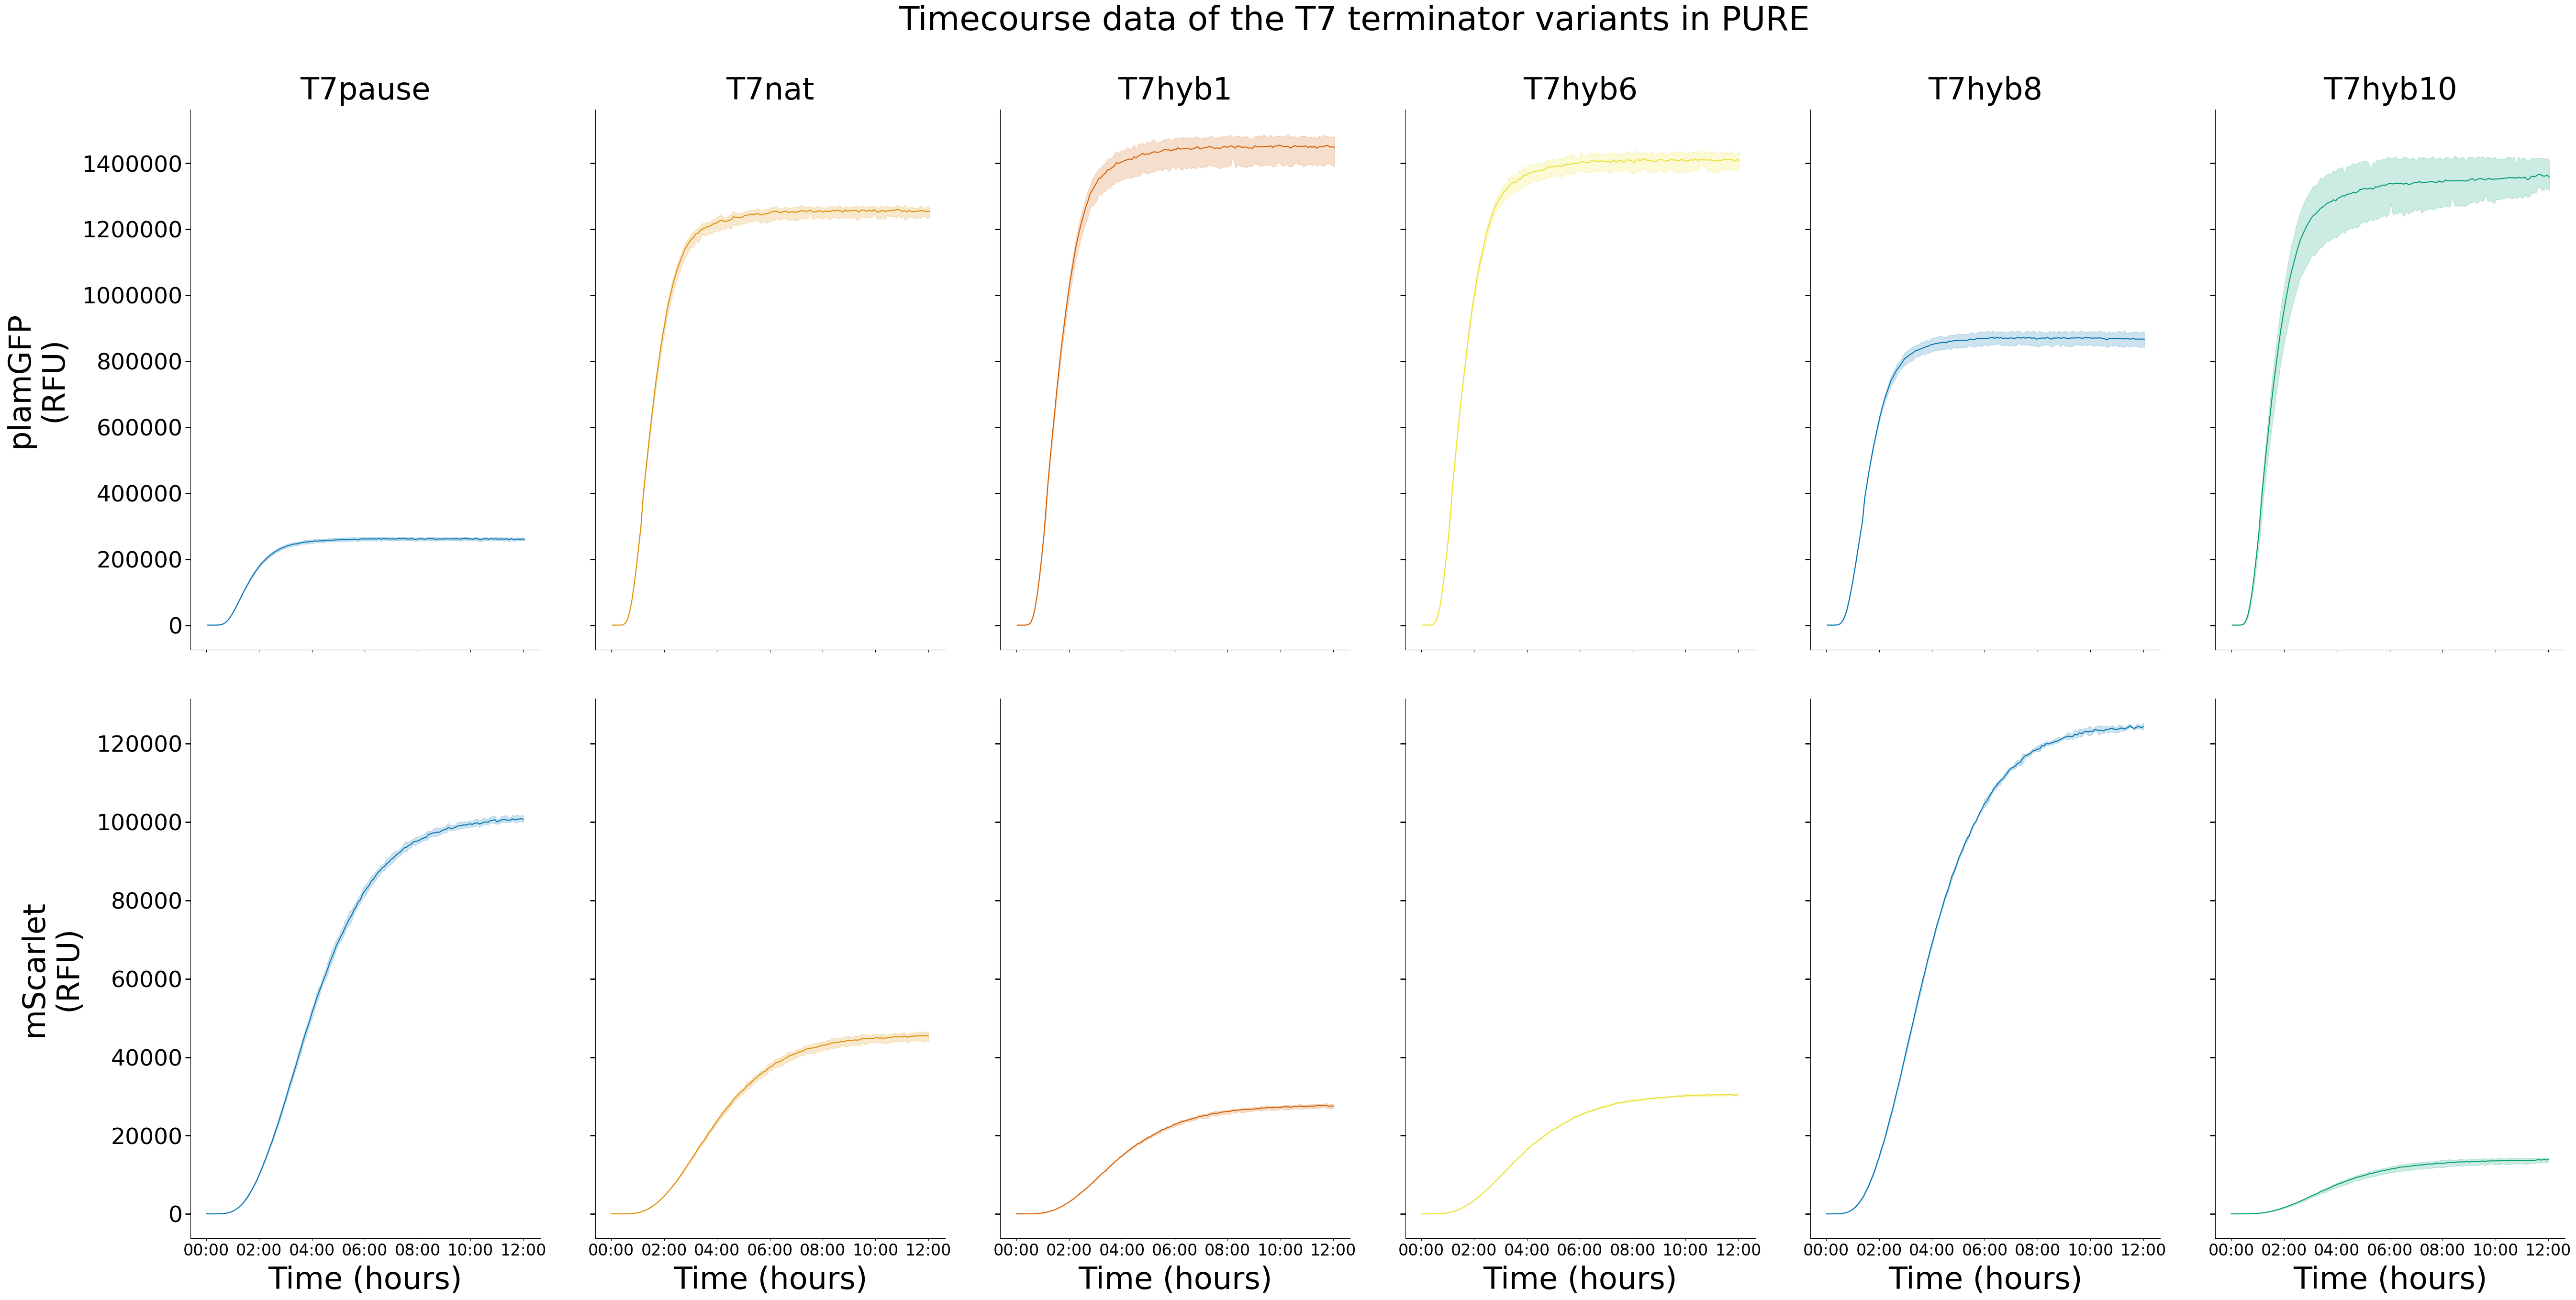

In [3]:
#| label: fig:kinetics
#pr.plot_curves(data, col="Read", row="Name", units="Well", facet_kws={"sharey":"col"},estimator =None, palette='colorblind')

Subset = ["T7pause", "T7nat", "T7hyb1", "T7hyb6", "T7hyb8","T7hyb10"]

terminator_colors = {
    "T7pause":  "#0173B2",  # Color #1: Dark Blue
    "T7nat":   "#DE8F05",  # Golden Orange
    "T7hyb1":  "#D55E00",  # Reddish-Orange
    "T7hyb6":  "#ECE133",  # Olive Yellow
    "T7hyb8":  "#0173B2",  # Dark Blue (Recycled from start of palette)
    "T7hyb10": "#029E73"   # Teal Green (Recycled from start of palette)
}


Summary_plot = pr.plot_curves(
    data[data["Name"].isin(Subset)], 
    col="Name", 
    row="Read", 
    #units="Well", 
    facet_kws={"sharey":"row"},
    row_order=["GFP-Gext", "mScarlet"],
    #estimator=None, 
    palette=terminator_colors,
    legend=None,
)

# Set plot size
Summary_plot.fig.set_size_inches(52,26)

# Ensure axes aren't exponents
for ax in Summary_plot.axes.flat:
    ax.ticklabel_format(style='plain', axis='y', useOffset=False)

# Update titles
Summary_plot.fig.suptitle("Timecourse data of the T7 terminator variants in PURE", 
                          fontsize=50, y=1.05)
Summary_plot.set_titles("") 
for ax, name in zip(Summary_plot.axes[0, :], Subset):
    ax.set_title(name,fontsize=46, pad=15)
    
# Set the X-axis label for all bottom plots
Summary_plot.set_xlabels("Time (hours)", fontsize=46, labelpad=10)

# Loop through all axes to format ticks and labels
for ax in Summary_plot.axes.flat:
    # Ensure axes aren't exponents
    ax.ticklabel_format(style='plain', axis='y', useOffset=False)
    # Make numbers on the axes larger
    ax.tick_params(axis='x', labelsize=24)
    ax.tick_params(axis='y', labelsize=34, length=8, width=2)
    
Summary_plot.axes[0, 0].set_ylabel('plamGFP\n(RFU)',fontsize=46, labelpad=20)
Summary_plot.axes[1, 0].set_ylabel('mScarlet\n(RFU)', fontsize=46, labelpad=20)
#plt.savefig("T7_terminator_kinetics.png", dpi=600, bbox_inches='tight')

plt.show()

# Plotting termination efficiencies 


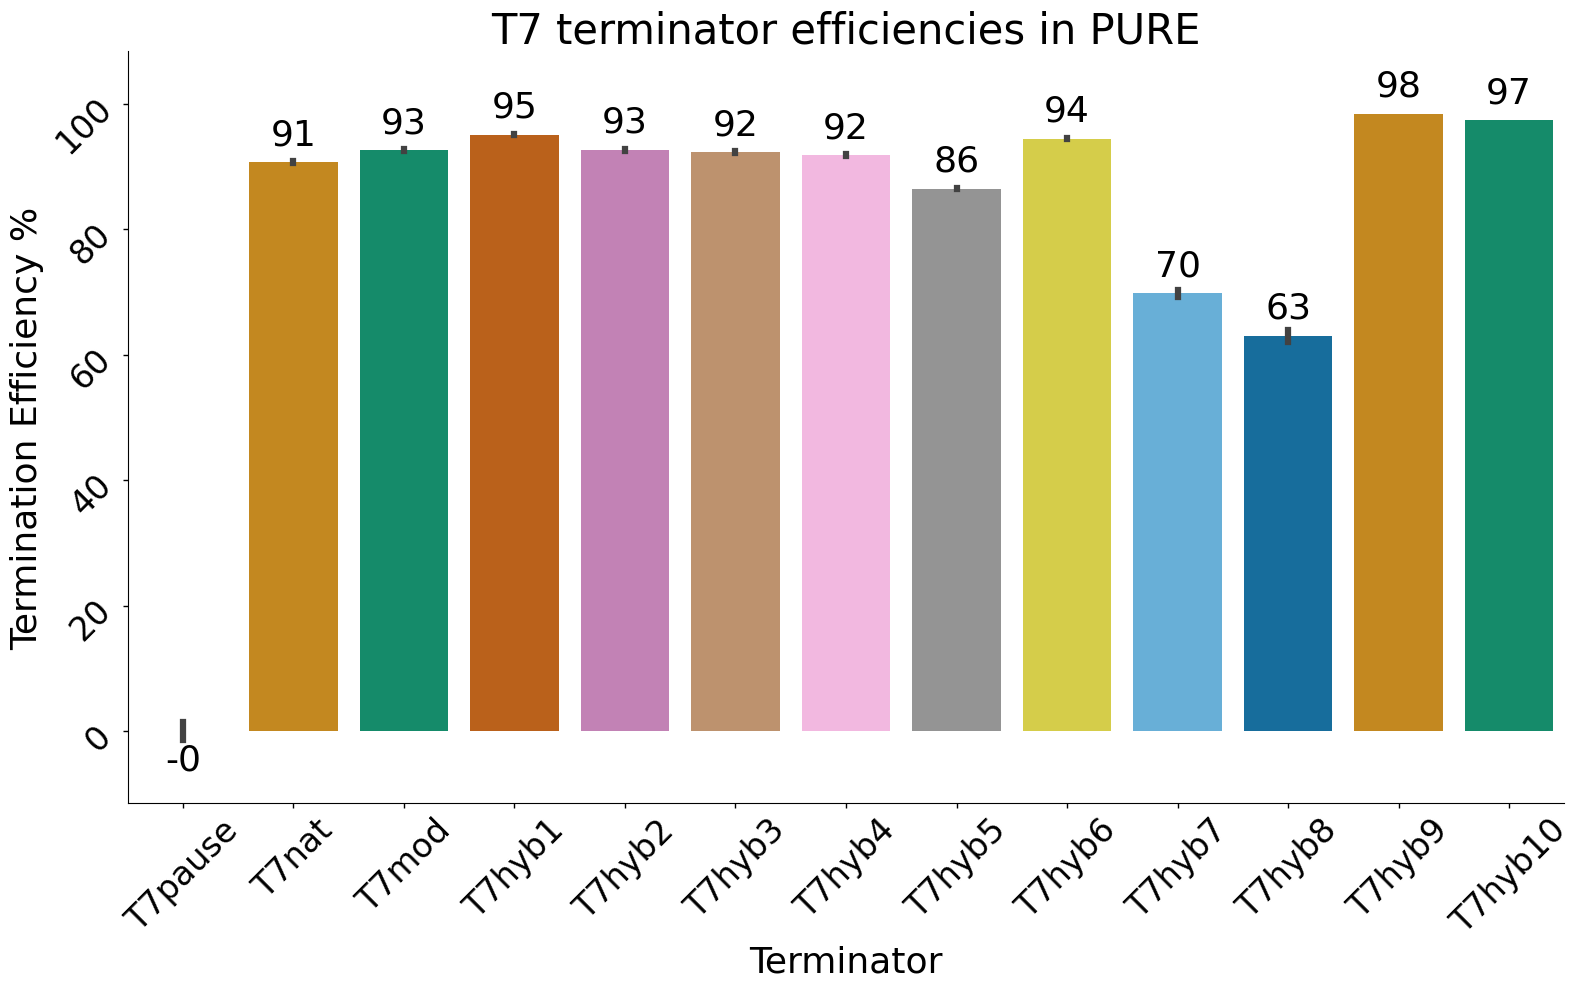

In [4]:
#| label: fig:termination_efficiency

# Retrieving endpoint fluorescence values and constructing a dataframe
endpoint_time = pd.Timedelta(hours=12)
endpoint_data = data.groupby(['Read', 'Well'])['Time'].apply(
    lambda x: (x - endpoint_time).abs().idxmin()
)

endpoint_df = data.loc[endpoint_data].copy()

endpoint_mScarlet = endpoint_df[endpoint_df["Read"] == "mScarlet"].sort_values("Well")
endpoint_plamGFP  = endpoint_df[endpoint_df["Read"] == "GFP-Gext"].sort_values("Well")

ratio_df = pd.merge(
    endpoint_mScarlet[['Well', 'Name', 'Data']], 
    endpoint_plamGFP[['Well', 'Name','Data']], 
    on="Well", 
    suffixes=('_mScarlet', '_plamGFP')
)

# Performing background substraction and termination efficiency calculations 

blanked_name = 'Negative'

mScarlet_blanked = ratio_df[ratio_df['Name_mScarlet'] == blanked_name]['Data_mScarlet'].mean()
plamGFP_blanked = ratio_df[ratio_df['Name_plamGFP'] == blanked_name]['Data_plamGFP'].mean()

ratio_df['mScarlet_blanked'] = ratio_df['Data_mScarlet'] - mScarlet_blanked
ratio_df['plamGFP_blanked']  = ratio_df['Data_plamGFP'] - plamGFP_blanked

ratio_df['Ratio_GFP_to_mScarlet'] = ratio_df['plamGFP_blanked'] / ratio_df['mScarlet_blanked']

T7pause_ratio = ratio_df.loc[ratio_df['Name_plamGFP'] == 'T7pause', 'Ratio_GFP_to_mScarlet'].mean()

ratio_df['Normalized_Ratio'] = ratio_df['Ratio_GFP_to_mScarlet'] / T7pause_ratio

ratio_df['Termination_Efficiency'] = (1 - (1 / ratio_df['Normalized_Ratio'])) * 100

# Plotting

plt.figure(figsize=(16, 10))

plot_order = [
    "T7pause",
    "T7nat",
    "T7mod",
    "T7hyb1",
    "T7hyb2",
    "T7hyb3",
    "T7hyb4",
    "T7hyb5",
    "T7hyb6",
    "T7hyb7",
    "T7hyb8",
    "T7hyb9",
    "T7hyb10",
]


sns.barplot(
    data=ratio_df,
    x='Name_mScarlet',
    y='Termination_Efficiency',
    errorbar="sd",
    errwidth=4.5,
    palette='colorblind',
    #edgecolor='black',
    order=plot_order,
)


for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.0f', padding=8, fontsize=26)
    
plt.margins(y=0.1) 
plt.title('T7 terminator efficiencies in PURE', fontsize=30)
plt.ylabel('Termination Efficiency %', fontsize='26')
plt.xlabel('Terminator', fontsize='26')
plt.tick_params(axis='x', rotation=45, labelsize=24, length=3.5, width=1)
plt.tick_params(axis='y', rotation=45, labelsize=24, length=3.5, width=1)
plt.grid(False)
plt.tight_layout()
sns.despine()
plt.savefig("../../figures/T7_terminator_collection_in_PURE.png", dpi=600)
plt.show()